# Purchase Frequency and Basket Size Analysis on Grocery Data

I rebuilt the grocery data at basket level instead of treating each item row as a separate transaction.  
The analysis focuses on how large each shopping basket is, how often customers return, which products dominate demand, how shopping changes by weekday, and which products tend to appear together.

The notebook also saves the main result tables and every chart into separate folders so the project can be reused without repeating the analysis manually.

## Loading and checking the grocery data

First load the original CSV and check its shape, columns, missing values, customer count, product count, and duplicate item lines. This gives me a clean reference point before creating any basket-level metrics.

In [2]:
# importing the libraries and setting project paths
from pathlib import Path
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 30)

base_dir = Path(r"C:\Users\anarrasulzada\Desktop\Week 4\task 3")

data_path = base_dir / "Groceries_dataset.csv"
visuals_dir = base_dir / "visuals"


visuals_dir.mkdir(exist_ok=True)

df = pd.read_csv(data_path)

df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [3]:
# checking the basic structure before building basket-level metrics
print("shape:", df.shape)
print("columns:", df.columns.tolist())
print("missing values:")
print(df.isna().sum())

print("\nunique customers:", df["Member_number"].nunique())
print("unique products:", df["itemDescription"].nunique())
print("exact duplicate item rows:", df.duplicated().sum())

df.dtypes.to_frame("dtype")

shape: (38765, 3)
columns: ['Member_number', 'Date', 'itemDescription']
missing values:
Member_number      0
Date               0
itemDescription    0
dtype: int64

unique customers: 3898
unique products: 167
exact duplicate item rows: 759


,dtype
Member_number,int64
Date,str
itemDescription,str


## To convert the date and creating time fields

The dates are stored as day-month-year strings, so I convert them with an explicit format instead of relying on automatic parsing. I also create weekday and month fields because both are used later in the operational analysis.

In [4]:
# converting the date column and creating reusable time fields
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df["weekday"] = df["Date"].dt.day_name()
df["year_month"] = df["Date"].dt.to_period("M").astype(str)

print("date range:", df["Date"].min().date(), "to", df["Date"].max().date())
df[["Date", "weekday", "year_month"]].head()

date range: 2014-01-01 to 2015-12-30


,Date,weekday,year_month
0,2015-07-21,Tuesday,2015-07
1,2015-01-05,Monday,2015-01
2,2015-09-19,Saturday,2015-09
3,2015-12-12,Saturday,2015-12
4,2015-02-01,Sunday,2015-02


## Keep repeated item lines in purchase counts

There are repeated rows where the same member bought the same product on the same date. I keep those rows for basket size and product popularity because this is item-level purchase data and repeated lines can represent repeated units.

For product co-occurrence, I handle this differently: each product is counted only once inside a basket so a repeated unit does not artificially multiply the same product pair.

In [5]:
# counting repeated item lines without removing them
repeated_item_lines = df.duplicated(
    subset=["Member_number", "Date", "itemDescription"]
).sum()

print("repeated member-date-item lines kept in purchase counts:", repeated_item_lines)

repeated member-date-item lines kept in purchase counts: 759


## Constructing baskets from member and shopping date

A basket is one unique `(Member_number, Date)` combination. Grouping on those two fields turns the item-level file into a visit-level table, where `basket_size` is the number of purchased item rows in that visit.

In [6]:
# grouping item rows into one basket per member and shopping date
basket_level = (
    df.groupby(["Member_number", "Date"])
      .size()
      .reset_index(name="basket_size")
)

basket_level["weekday"] = basket_level["Date"].dt.day_name()
basket_level["year_month"] = basket_level["Date"].dt.to_period("M").astype(str)

basket_summary = pd.Series({
    "total_baskets": len(basket_level),
    "average_basket_size": basket_level["basket_size"].mean(),
    "median_basket_size": basket_level["basket_size"].median(),
    "minimum_basket_size": basket_level["basket_size"].min(),
    "maximum_basket_size": basket_level["basket_size"].max()
})

basket_summary

total_baskets          14963.000000
average_basket_size        2.590724
median_basket_size         2.000000
minimum_basket_size        2.000000
maximum_basket_size       11.000000
dtype: float64

## Looking at the basket-size distribution

The histogram shows whether shopping visits are mostly small convenience baskets or larger stock-up trips. I keep integer-width bins because basket size is a discrete count.

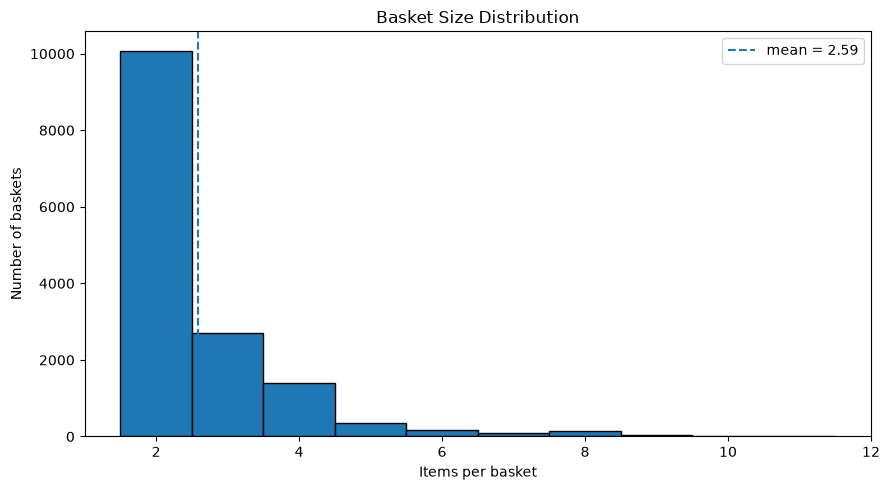

In [7]:
# plotting the basket-size distribution
fig, ax = plt.subplots(figsize=(9, 5))

bins = np.arange(
    basket_level["basket_size"].min() - 0.5,
    basket_level["basket_size"].max() + 1.5,
    1
)

ax.hist(basket_level["basket_size"], bins=bins, edgecolor="black")
ax.axvline(
    basket_level["basket_size"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f'mean = {basket_level["basket_size"].mean():.2f}'
)

ax.set_title("Basket Size Distribution")
ax.set_xlabel("Items per basket")
ax.set_ylabel("Number of baskets")
ax.legend()

plt.tight_layout()
plt.savefig(visuals_dir / "basket_size_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

In [8]:
# summarizing the exact basket-size counts and shares
basket_size_counts = basket_level["basket_size"].value_counts().sort_index()
basket_size_share = (
    basket_size_counts
    .div(len(basket_level))
    .mul(100)
    .round(2)
    .rename("share_pct")
)

pd.concat(
    [basket_size_counts.rename("basket_count"), basket_size_share],
    axis=1
)

,basket_count,share_pct
basket_size,,
2,10080,67.37
3,2698,18.03
4,1390,9.29
5,344,2.30
6,175,1.17
7,80,0.53
8,145,0.97
9,50,0.33
11,1,0.01


## Customer purchase frequency

Purchase frequency is the number of unique shopping days per customer. Counting unique dates avoids inflating visit frequency when several products were bought during the same trip.

In [9]:
# counting unique shopping days for each customer
customer_frequency = (
    df.groupby("Member_number")["Date"]
      .nunique()
      .reset_index(name="visits")
      .sort_values(["visits", "Member_number"], ascending=[False, True])
)

customer_frequency["visits"].describe()

count    3898.000000
mean        3.838635
std         1.883678
min         1.000000
25%         2.000000
50%         4.000000
75%         5.000000
max        11.000000
Name: visits, dtype: float64

## Grouping customers by visit frequency

The task wording contains an overlap between `6–10 visits` and `10+ visits`. I keep the groups mutually exclusive by using `11+ visits` as the final bucket. That keeps every customer in exactly one segment while preserving the requested 6–10 range.

In [10]:
# assigning each customer to one mutually exclusive frequency group
frequency_labels = ["1 visit", "2–5 visits", "6–10 visits", "11+ visits"]

customer_frequency["frequency_segment"] = pd.cut(
    customer_frequency["visits"],
    bins=[0, 1, 5, 10, np.inf],
    labels=frequency_labels
)

frequency_segments = (
    customer_frequency["frequency_segment"]
    .value_counts()
    .reindex(frequency_labels)
    .rename_axis("frequency_segment")
    .reset_index(name="customers")
)

frequency_segments["share_pct"] = (
    frequency_segments["customers"]
    .div(customer_frequency["Member_number"].nunique())
    .mul(100)
    .round(2)
)

frequency_segments

,frequency_segment,customers,share_pct
0,1 visit,349,8.95
1,2–5 visits,2819,72.32
2,6–10 visits,725,18.60
3,11+ visits,5,0.13


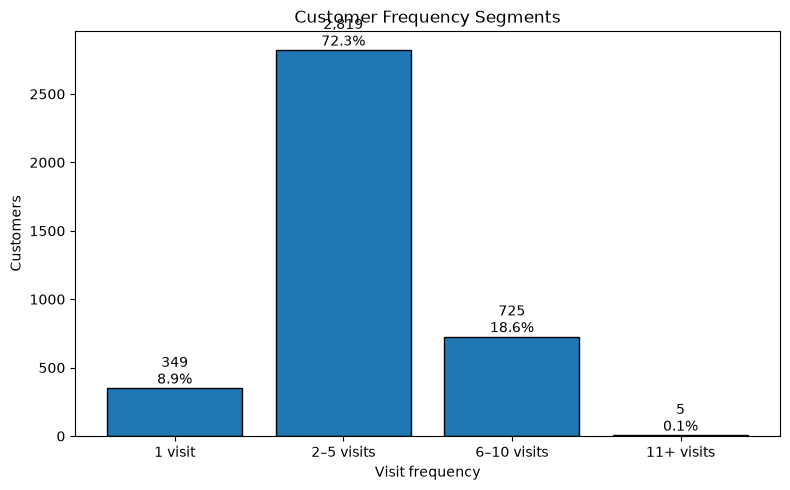

In [11]:
# plotting the customer frequency segments
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    frequency_segments["frequency_segment"],
    frequency_segments["customers"],
    edgecolor="black"
)

for i, row in frequency_segments.iterrows():
    ax.text(
        i,
        row["customers"],
        f'{row["customers"]:,}\n{row["share_pct"]:.1f}%',
        ha="center",
        va="bottom"
    )

ax.set_title("Customer Frequency Segments")
ax.set_xlabel("Visit frequency")
ax.set_ylabel("Customers")

plt.tight_layout()
plt.savefig(visuals_dir / "customer_frequency_segments.png", dpi=180, bbox_inches="tight")
plt.show()

## Ranking the most purchased products

Product popularity is based on item-row purchase count. This answers a different question from basket penetration: it measures how many product units/lines were recorded, not just how many baskets contained the item.

In [12]:
# ranking products by their total recorded purchase count
top_products = (
    df["itemDescription"]
    .value_counts()
    .rename_axis("product")
    .reset_index(name="purchase_count")
)

top20_products = top_products.head(20)
top20_products

,product,purchase_count
0,whole milk,2502
1,other vegetables,1898
2,rolls/buns,1716
3,soda,1514
4,yogurt,1334
5,root vegetables,1071
6,tropical fruit,1032
7,bottled water,933
8,sausage,924
9,citrus fruit,812


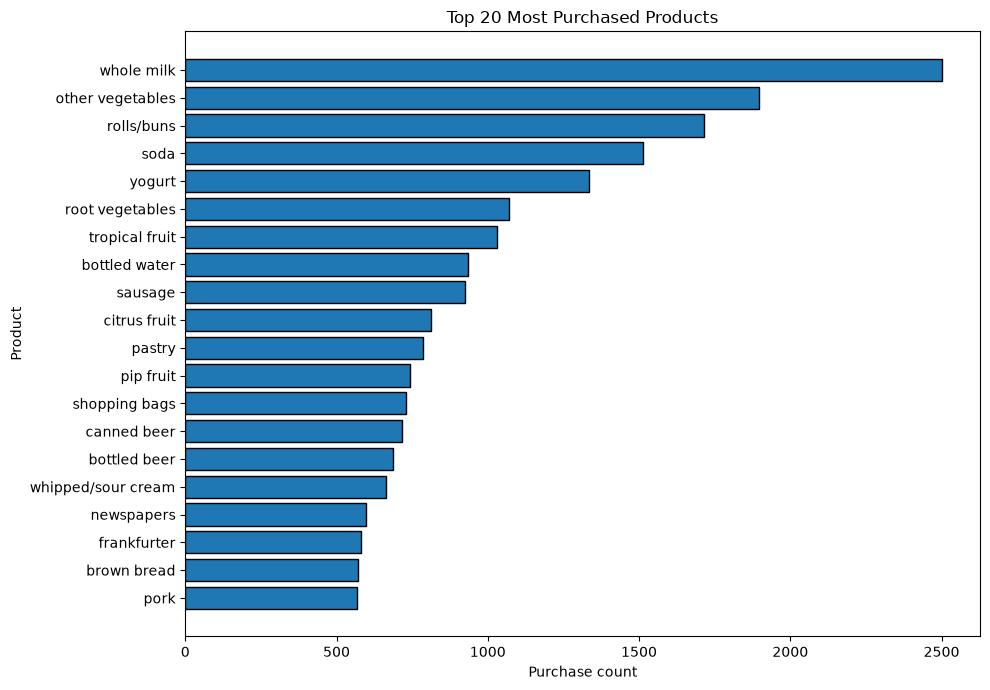

In [13]:
# plotting the twenty most purchased products
plot_data = top20_products.sort_values("purchase_count")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    plot_data["product"],
    plot_data["purchase_count"],
    edgecolor="black"
)

ax.set_title("Top 20 Most Purchased Products")
ax.set_xlabel("Purchase count")
ax.set_ylabel("Product")

plt.tight_layout()
plt.savefig(visuals_dir / "top_20_products.png", dpi=180, bbox_inches="tight")
plt.show()

## Comparing transaction volume across weekdays

Here, a transaction means one basket rather than one item row. This makes the weekday comparison operationally meaningful because it reflects shopping visits that affect checkout traffic and staffing.

In [14]:
# ordering weekdays consistently for the operational comparisons
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_transactions = (
    basket_level.groupby("weekday")
    .size()
    .reindex(weekday_order)
    .rename("basket_count")
    .reset_index()
)

weekday_transactions

,weekday,basket_count
0,Monday,2067
1,Tuesday,2142
2,Wednesday,2131
3,Thursday,2188
4,Friday,2136
5,Saturday,2161
6,Sunday,2138


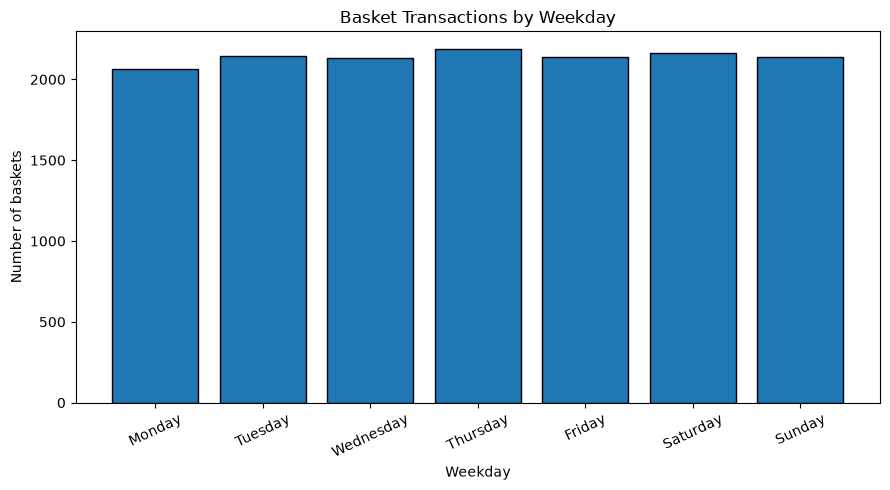

In [15]:
# plotting basket traffic across weekdays
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    weekday_transactions["weekday"],
    weekday_transactions["basket_count"],
    edgecolor="black"
)

ax.set_title("Basket Transactions by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Number of baskets")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(visuals_dir / "weekday_transaction_volume.png", dpi=180, bbox_inches="tight")
plt.show()

## Comparing average basket size by weekday

Transaction volume and basket size do not have to peak on the same day. I calculate the average number of items per basket for each weekday to separate store traffic from basket depth.

In [16]:
# calculating average basket size for each weekday
weekday_avg_basket = (
    basket_level.groupby("weekday")["basket_size"]
    .mean()
    .reindex(weekday_order)
    .rename("avg_basket_size")
    .reset_index()
)

weekday_avg_basket["avg_basket_size"] = weekday_avg_basket["avg_basket_size"].round(3)
weekday_avg_basket

,weekday,avg_basket_size
0,Monday,2.604
1,Tuesday,2.595
2,Wednesday,2.610
3,Thursday,2.569
4,Friday,2.604
5,Saturday,2.569
6,Sunday,2.587


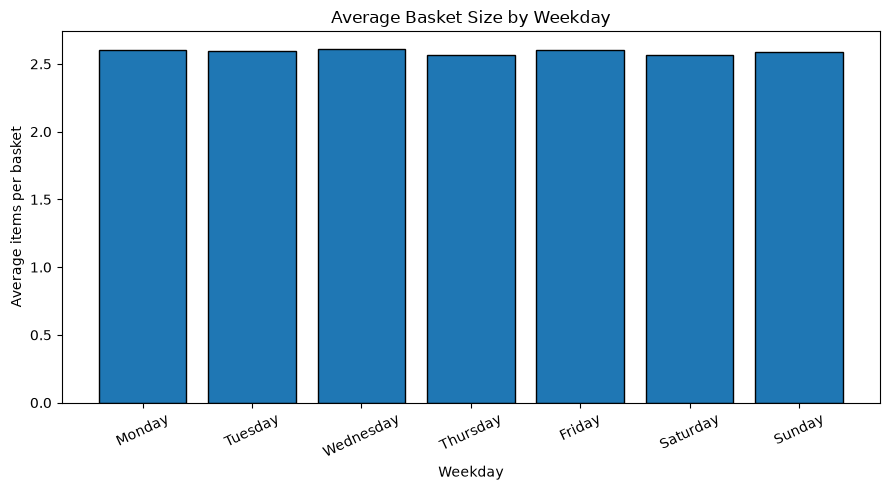

In [17]:
# plotting average basket size across weekdays
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    weekday_avg_basket["weekday"],
    weekday_avg_basket["avg_basket_size"],
    edgecolor="black"
)

ax.set_title("Average Basket Size by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Average items per basket")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(visuals_dir / "avg_basket_size_by_weekday.png", dpi=180, bbox_inches="tight")
plt.show()

## Which products appear together?

For the co-occurrence bonus, I convert every basket to a set of unique products and count all two-item combinations. Using unique products here prevents duplicate units of the same item from overstating pair frequency.

In [18]:
# building unique product sets before counting co-occurring pairs
basket_products = (
    df.groupby(["Member_number", "Date"])["itemDescription"]
      .apply(lambda items: sorted(set(items)))
)

pair_counter = Counter()

for items in basket_products:
    pair_counter.update(combinations(items, 2))

top_pairs = pd.DataFrame(
    pair_counter.most_common(20),
    columns=["product_pair", "basket_count"]
)

top_pairs["pair_label"] = top_pairs["product_pair"].apply(
    lambda pair: f"{pair[0]} + {pair[1]}"
)

top_pairs.head(10)

,product_pair,basket_count,pair_label
0,"(other vegetables, whole milk)",222,other vegetables + whole milk
1,"(rolls/buns, whole milk)",209,rolls/buns + whole milk
2,"(soda, whole milk)",174,soda + whole milk
3,"(whole milk, yogurt)",167,whole milk + yogurt
4,"(other vegetables, rolls/buns)",158,other vegetables + rolls/buns
5,"(other vegetables, soda)",145,other vegetables + soda
6,"(sausage, whole milk)",134,sausage + whole milk
7,"(tropical fruit, whole milk)",123,tropical fruit + whole milk
8,"(other vegetables, yogurt)",121,other vegetables + yogurt
9,"(rolls/buns, soda)",121,rolls/buns + soda


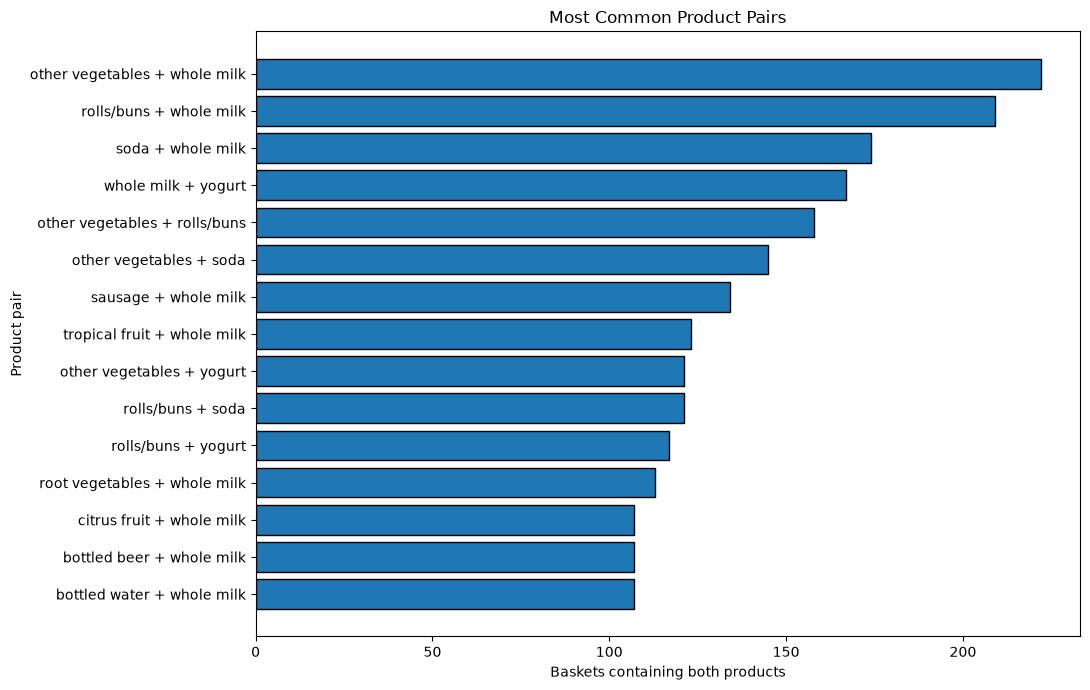

In [19]:
# plotting the most frequent two-product combinations
plot_pairs = top_pairs.head(15).sort_values("basket_count")

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(
    plot_pairs["pair_label"],
    plot_pairs["basket_count"],
    edgecolor="black"
)

ax.set_title("Most Common Product Pairs")
ax.set_xlabel("Baskets containing both products")
ax.set_ylabel("Product pair")

plt.tight_layout()
plt.savefig(visuals_dir / "top_product_pairs.png", dpi=180, bbox_inches="tight")
plt.show()

## Following the most active customers month by month

The second bonus looks at the ten customers with the highest basket counts. I use a month-by-customer matrix so it is easy to see whether their shopping is concentrated in a few months or spread across the two-year period.

In [20]:
# selecting the ten customers with the most shopping visits
top10_customers = (
    customer_frequency
    .sort_values(["visits", "Member_number"], ascending=[False, True])
    .head(10)["Member_number"]
    .tolist()
)

shopping_days = df.drop_duplicates(subset=["Member_number", "Date"]).copy()

top10_monthly = (
    shopping_days[shopping_days["Member_number"].isin(top10_customers)]
    .groupby(["Member_number", "year_month"])
    .size()
    .unstack(fill_value=0)
)

all_months = pd.period_range(
    df["Date"].min().to_period("M"),
    df["Date"].max().to_period("M"),
    freq="M"
).astype(str)

top10_monthly = top10_monthly.reindex(
    index=top10_customers,
    columns=all_months,
    fill_value=0
)

top10_monthly

,2014-01,2014-02,2014-03,2014-04,2014-05,2014-06,2014-07,2014-08,2014-09,2014-10,2014-11,2014-12,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12
Member_number,,,,,,,,,,,,,,,,,,,,,,,,
1379,0,1,0,0,0,2,1,0,1,0,0,0,0,1,0,1,1,0,3,0,0,0,0,0
2193,1,0,0,1,0,0,0,0,1,2,1,0,1,0,0,2,0,0,0,0,2,0,0,0
2271,0,1,0,0,0,1,1,1,2,0,0,0,2,0,0,0,0,1,0,1,0,0,1,0
3737,1,0,0,1,0,0,1,0,1,0,0,2,0,0,1,0,1,0,0,0,0,0,1,2
4338,0,0,0,2,0,0,1,0,0,2,0,0,1,0,1,0,0,1,0,1,1,1,0,0
1052,2,0,1,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0,1,0,0,1,0,0
1275,1,0,0,0,0,2,0,0,0,0,1,0,0,1,0,1,1,1,1,0,0,1,0,0
1410,1,2,0,0,1,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0
1574,1,2,1,1,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0


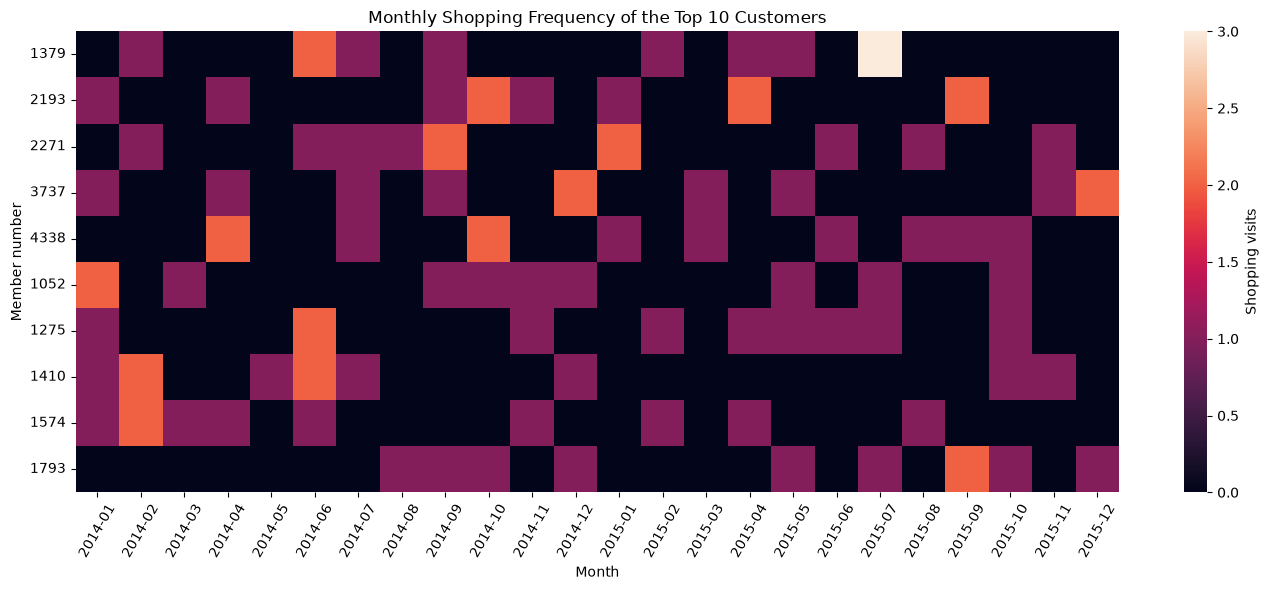

In [21]:
# visualizing monthly visit frequency for the most active customers
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    top10_monthly,
    ax=ax,
    cbar_kws={"label": "Shopping visits"}
)

ax.set_title("Monthly Shopping Frequency of the Top 10 Customers")
ax.set_xlabel("Month")
ax.set_ylabel("Member number")
ax.tick_params(axis="x", rotation=60)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(
    visuals_dir / "top10_customers_monthly_frequency.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

## To check how concentrated the customer base is

A high concentration would mean that a small number of customers drive a large share of shopping trips. I compare the top ten customers with all baskets to see whether that risk exists here.

In [22]:
# measuring how much of total basket activity comes from the top ten customers
top10_basket_count = (
    customer_frequency
    .sort_values(["visits", "Member_number"], ascending=[False, True])
    .head(10)["visits"]
    .sum()
)

top10_share = top10_basket_count / len(basket_level) * 100

print("top 10 customer baskets:", top10_basket_count)
print(f"share of all baskets: {top10_share:.2f}%")

top 10 customer baskets: 105
share of all baskets: 0.70%


## Summarize the main findings

Kept the final summary short and tied to store decisions: basket depth, repeat behavior, staple demand, weekday traffic, and cross-selling opportunities.

In [23]:
# collecting the main project findings in one compact summary
size_two_share = (
    (basket_level["basket_size"] == 2).mean() * 100
)

summary = {
    "rows": len(df),
    "customers": df["Member_number"].nunique(),
    "products": df["itemDescription"].nunique(),
    "baskets": len(basket_level),
    "avg_basket_size": round(basket_level["basket_size"].mean(), 2),
    "median_basket_size": int(basket_level["basket_size"].median()),
    "max_basket_size": int(basket_level["basket_size"].max()),
    "two_item_basket_share_pct": round(size_two_share, 2),
    "most_purchased_product": top20_products.iloc[0]["product"],
    "most_purchased_product_count": int(top20_products.iloc[0]["purchase_count"]),
    "busiest_weekday": weekday_transactions.loc[
        weekday_transactions["basket_count"].idxmax(), "weekday"
    ],
    "highest_avg_basket_weekday": weekday_avg_basket.loc[
        weekday_avg_basket["avg_basket_size"].idxmax(), "weekday"
    ],
    "most_common_pair": top_pairs.iloc[0]["pair_label"],
    "most_common_pair_baskets": int(top_pairs.iloc[0]["basket_count"]),
    "top10_customer_basket_share_pct": round(top10_share, 2)
}

pd.Series(summary)

rows                                                       38765
customers                                                   3898
products                                                     167
baskets                                                    14963
avg_basket_size                                             2.59
median_basket_size                                             2
max_basket_size                                               11
two_item_basket_share_pct                                  67.37
most_purchased_product                                whole milk
most_purchased_product_count                                2502
busiest_weekday                                         Thursday
highest_avg_basket_weekday                             Wednesday
most_common_pair                   other vegetables + whole milk
most_common_pair_baskets                                     222
top10_customer_basket_share_pct                              0.7
dtype: object